# Flight Delay Analysis & Prediction

## Project Overview

This project analyses historical flight data to investigate patterns associated with arrival delays and to develop a supervised machine learning model for estimating whether a flight is likely to arrive at least 15 minutes late.

The analysis covers data preparation, exploratory analysis, descriptive statistics, correlation analysis, hypothesis testing, predictive modelling and an interactive Streamlit application.

## Business Problem

Flight delays can affect passengers, airline operations and scheduling decisions. The project investigates where delay patterns are concentrated and provides a predictive component that can support proactive operational attention.

## Main Questions

1. What is the overall flight delay rate?
2. How does the delay rate vary between airlines?
3. How does delay frequency vary by month?
4. Is departure delay significantly related to arrival delay?
5. Can scheduled flight information be used to estimate the likelihood of an arrival delay?

## 1. Data Loading

The project uses the public 2018 flight dataset stored as a Parquet file. The full dataset is loaded with pandas so that the analysis can work consistently from the original source data.

In [1]:
import pandas as pd

file_path = "../data/Combined_Flights_2018.parquet"

df = pd.read_parquet(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 5689512
Columns: 61


,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,...,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,...,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,...,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0


## 2. Initial Data Inspection

The first inspection checks the dataset dimensions, available columns, data types and missing values before any transformations are applied.

In [2]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values - top 20:")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\nSample:")
display(df.head(3))

Dataset shape: (5689512, 61)

Column names:
['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,...,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,...,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0


In [3]:
print("Delayed flights (ArrDel15):")
print(df["ArrDel15"].value_counts(dropna=False))

print("\nArrival delay summary:")
print(df["ArrDelay"].describe())

print("\nCancellation:")
print(df["Cancelled"].value_counts(dropna=False))

print("\nDiversion:")
print(df["Diverted"].value_counts(dropna=False))

Delayed flights (ArrDel15):
ArrDel15
0.0    4498277
1.0    1088342
NaN     102893
Name: count, dtype: int64

Arrival delay summary:
count    5.586619e+06
mean     5.416295e+00
std      4.746066e+01
min     -1.290000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      8.000000e+00
max      2.635000e+03
Name: ArrDelay, dtype: float64

Cancellation:
Cancelled
False    5601139
True       88373
Name: count, dtype: int64

Diversion:
Diverted
False    5675557
True       13955
Name: count, dtype: int64


## 3. Data Cleaning and ETL

Cancelled and diverted flights are excluded because the main analytical target is whether a completed flight arrived at least 15 minutes late.

Rows with a missing `ArrDel15` value are removed before creating the binary target. The original `df` object is kept unchanged and a working copy named `flights` is used for analysis.

In [4]:
# Keep a working copy of the raw data
flights = df.copy()

# Remove cancelled and diverted flights for the delay prediction analysis
flights = flights[
    (flights["Cancelled"] == 0) &
    (flights["Diverted"] == 0)
].copy()

print("Rows after removing cancelled/diverted flights:", len(flights))

Rows after removing cancelled/diverted flights: 5587186


In [5]:
# Check missing values in the prediction target
print("Missing ArrDel15 values:", flights["ArrDel15"].isna().sum())

Missing ArrDel15 values: 567


In [6]:
# Remove rows where the target is missing
flights = flights.dropna(subset=["ArrDel15"]).copy()

# Create the binary prediction target
flights["Delayed"] = flights["ArrDel15"].astype(int)

print(flights["Delayed"].value_counts())
print(flights["Delayed"].value_counts(normalize=True) * 100)

Delayed
0    4498277
1    1088342
Name: count, dtype: int64
Delayed
0    80.518772
1    19.481228
Name: proportion, dtype: float64


## 4. Feature Engineering

The dataset contains scheduled departure and arrival times in HHMM format. Time-based features are created for month, day of week, departure hour and arrival hour.

Scheduled duration is calculated by converting HHMM values to minutes and handling flights that cross midnight.

For prediction, only information available before departure is used. Arrival delay and departure delay are deliberately excluded from the model features to avoid data leakage.

In [7]:
# Create scheduled flight duration correctly from HHMM times

def hhmm_to_minutes(value):
    value = int(value)
    hours = value // 100
    minutes = value % 100
    return hours * 60 + minutes


dep_minutes = flights["CRSDepTime"].apply(hhmm_to_minutes)
arr_minutes = flights["CRSArrTime"].apply(hhmm_to_minutes)

duration = arr_minutes - dep_minutes

# Extract scheduled departure and arrival hours
flights["DepHour"] = (flights["CRSDepTime"] // 100).astype(int)
flights["ArrHour"] = (flights["CRSArrTime"] // 100).astype(int)

# Handle flights that cross midnight
duration = duration.where(duration >= 0, duration + 24 * 60)

flights["ScheduledDuration"] = duration

print(flights["ScheduledDuration"].describe())

count    5.586619e+06
mean     1.406653e+02
std      1.031026e+02
min      0.000000e+00
25%      8.000000e+01
50%      1.120000e+02
75%      1.700000e+02
max      1.439000e+03
Name: ScheduledDuration, dtype: float64


In [8]:
features = [
    "Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime",
    "Distance",
    "Month",
    "DayOfWeek",
    "DepHour",
    "ArrHour",
    "ScheduledDuration"
]

X = flights[features].copy()
y = flights["Delayed"].copy()

print("Model feature shape:", X.shape)
print("Target shape:", y.shape)
print("Missing values in model inputs:", X.isna().sum().sum())

Model feature shape: (5586619, 11)
Target shape: (5586619,)
Missing values in model inputs: 0


## 5. Statistical Analysis

Descriptive statistics are used to summarise the distribution of important numerical variables. Mean, median and standard deviation provide measures of central tendency and spread, while variance provides an additional measure of dispersion.

In [9]:
stats_summary = flights[
    ["DepDelay", "ArrDelay", "Distance", "TaxiOut", "TaxiIn"]
].describe().T

stats_summary["variance"] = flights[
    ["DepDelay", "ArrDelay", "Distance", "TaxiOut", "TaxiIn"]
].var()

stats_summary[
    ["mean", "50%", "std", "variance", "min", "max"]
].round(2)

,mean,50%,std,variance,min,max
DepDelay,10.08,-2.0,45.20,2043.29,-1280.0,2625.0
ArrDelay,5.42,-6.0,47.46,2252.51,-1290.0,2635.0
Distance,790.03,628.0,595.29,354374.07,16.0,4983.0
TaxiOut,17.03,14.0,9.77,95.50,0.0,196.0
TaxiIn,7.36,6.0,5.87,34.44,0.0,259.0


## 6. Exploratory Data Analysis

The exploratory analysis focuses on overall delay levels, differences between airlines and monthly patterns. These views help identify operational patterns that can be interpreted in a business context.

In [10]:
# Overall flight delay statistics

total_flights = len(flights)
delayed_flights = flights["Delayed"].sum()
delay_rate = delayed_flights / total_flights * 100

print(f"Total flights analysed: {total_flights:,}")
print(f"Delayed flights: {delayed_flights:,}")
print(f"Overall delay rate: {delay_rate:.2f}%")

print("\nArrival delay statistics (minutes):")
print(flights["ArrDelay"].describe())

Total flights analysed: 5,586,619
Delayed flights: 1,088,342
Overall delay rate: 19.48%

Arrival delay statistics (minutes):
count    5.586619e+06
mean     5.416295e+00
std      4.746066e+01
min     -1.290000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      8.000000e+00
max      2.635000e+03
Name: ArrDelay, dtype: float64


In [11]:
# Delay rate by airline

airline_summary = (
    flights.groupby("Airline")
    .agg(
        Flights=("Delayed", "size"),
        Delayed=("Delayed", "sum"),
        Average_Arrival_Delay=("ArrDelay", "mean")
    )
)

airline_summary["Delay_Rate"] = (
    airline_summary["Delayed"] / airline_summary["Flights"] * 100
)

airline_summary = airline_summary.sort_values("Delay_Rate", ascending=False)

airline_summary

,Flights,Delayed,Average_Arrival_Delay,Delay_Rate
Airline,,,,
"Commutair Aka Champlain Enterprises, Inc.",45509,14597,21.579446,32.074974
Frontier Airlines Inc.,117523,34229,14.213311,29.125363
Peninsula Airways Inc.,1123,307,7.485307,27.337489
JetBlue Airways,297758,81308,11.432516,27.306739
Trans States Airlines,64664,15982,13.914852,24.715452
Capital Cargo International,41818,9473,6.588072,22.652925
Allegiant Air,95192,21231,9.983518,22.303345
ExpressJet Airlines Inc.,161955,34502,8.800352,21.303448
American Airlines Inc.,378722,78362,6.514280,20.691167


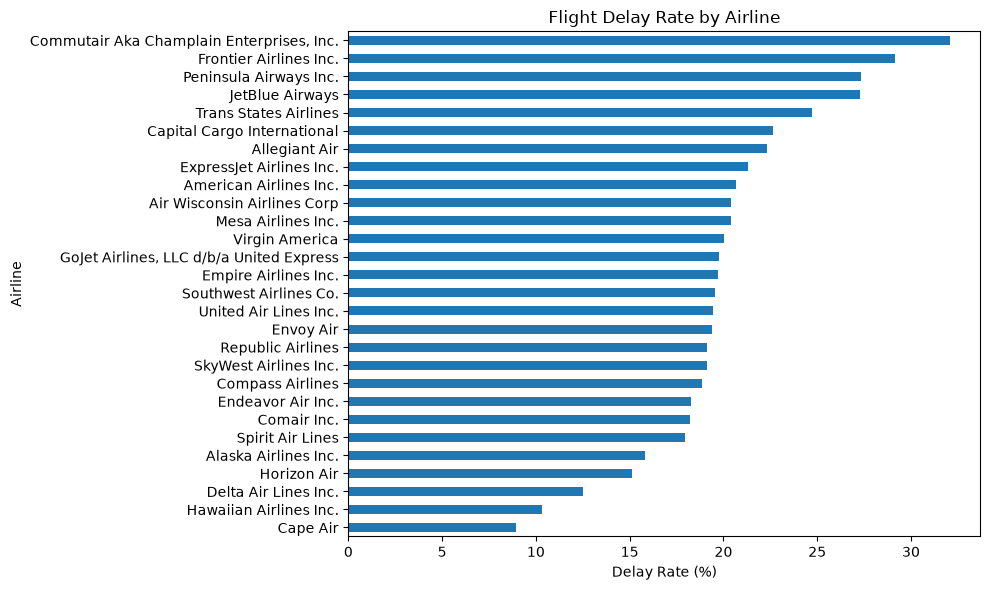

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

airline_summary["Delay_Rate"].sort_values().plot(kind="barh")

plt.title("Flight Delay Rate by Airline")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

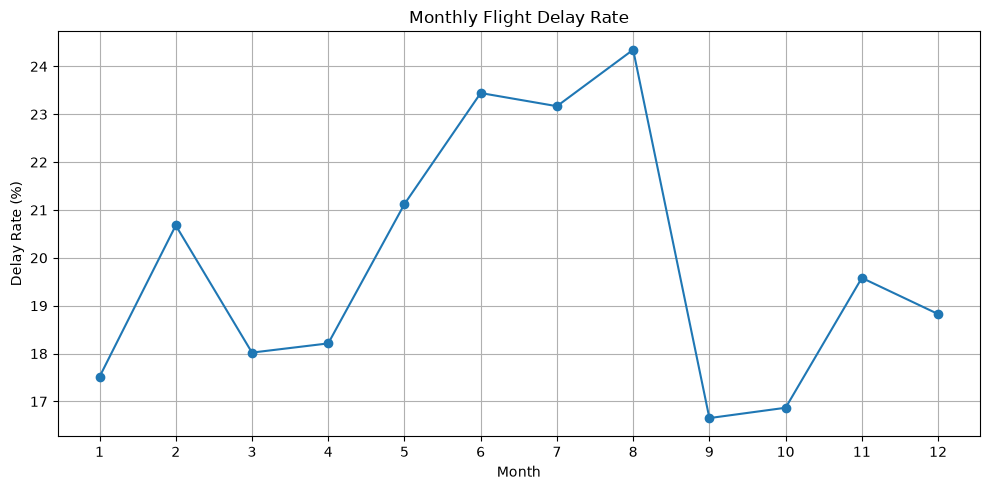

In [13]:
monthly_delay = (
    flights.groupby("Month")["Delayed"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))
monthly_delay.plot(marker="o")

plt.title("Monthly Flight Delay Rate")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

Correlation analysis is used to examine relationships between key numerical flight variables. The heatmap provides a compact visual overview of these relationships.

In [14]:
# Correlation between key numerical variables

numeric_cols = [
    "DepDelay",
    "ArrDelay",
    "Distance",
    "TaxiOut",
    "TaxiIn"
]

correlation_matrix = flights[numeric_cols].corr()

correlation_matrix

,DepDelay,ArrDelay,Distance,TaxiOut,TaxiIn
DepDelay,1.000000,0.959378,0.010144,0.059332,0.011669
ArrDelay,0.959378,1.000000,-0.017161,0.216379,0.103253
Distance,0.010144,-0.017161,1.000000,0.041772,0.071191
TaxiOut,0.059332,0.216379,0.041772,1.000000,0.034536
TaxiIn,0.011669,0.103253,0.071191,0.034536,1.000000


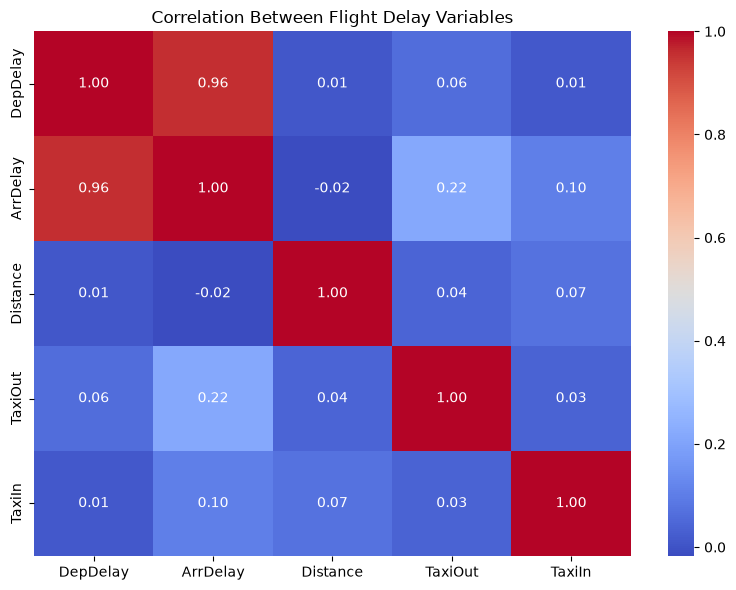

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Flight Delay Variables")
plt.tight_layout()
plt.show()

## 8. Hypothesis Testing

### Business Question

Does a departure delay have a statistically significant relationship with arrival delay?

### Null Hypothesis (H0)

There is no statistically significant relationship between departure delay and arrival delay.

### Alternative Hypothesis (H1)

There is a statistically significant relationship between departure delay and arrival delay.

A significance level of 0.05 is used. The Pearson correlation test provides both the correlation coefficient and a p-value.

In [16]:
from scipy.stats import pearsonr

test_data = flights[["DepDelay", "ArrDelay"]].dropna()

correlation, p_value = pearsonr(
    test_data["DepDelay"],
    test_data["ArrDelay"]
)

print(f"Pearson correlation: {correlation:.3f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant relationship between departure and arrival delay.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant relationship.")

Pearson correlation: 0.959
P-value: 0.000000
Result: Reject the null hypothesis.
There is a statistically significant relationship between departure and arrival delay.


In [17]:
print(f"Correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject H0.")
    print("Conclusion: The relationship is statistically significant.")
else:
    print("Decision: Fail to reject H0.")
    print("Conclusion: The evidence is insufficient to establish a significant relationship.")

Correlation coefficient: 0.959
P-value: 0.000000
Decision: Reject H0.
Conclusion: The relationship is statistically significant.


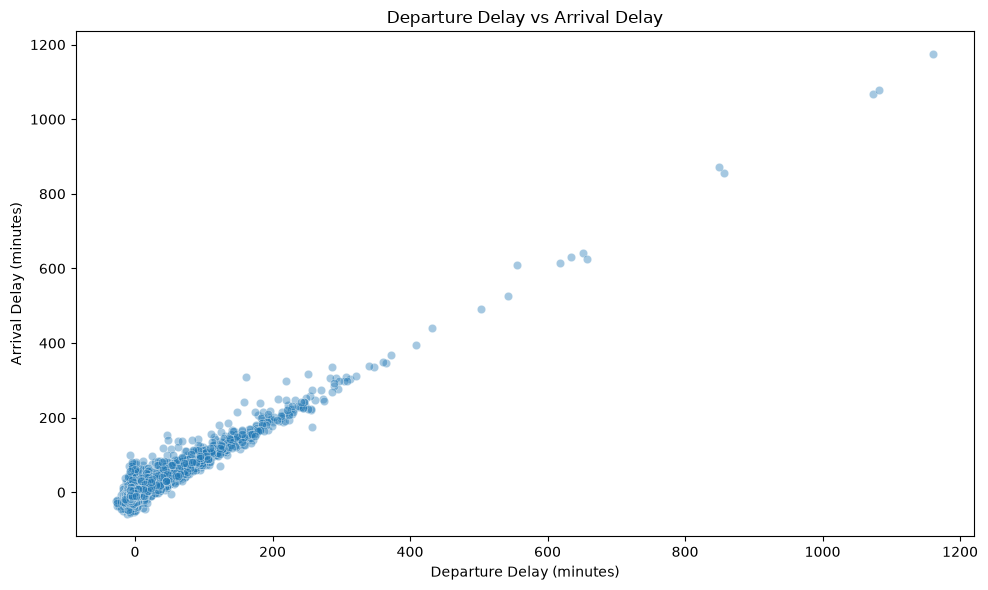

In [18]:
plt.figure(figsize=(10, 6))

sample = test_data.sample(
    min(10000, len(test_data)),
    random_state=42
)

sns.scatterplot(
    data=sample,
    x="DepDelay",
    y="ArrDelay",
    alpha=0.4
)

plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.tight_layout()
plt.show()

## 9. Machine Learning

The prediction task is a binary classification problem where `Delayed = 1` indicates an arrival delay of 15 minutes or more.

The dataset is split into training and testing sets using stratification so that the target distribution is maintained across both sets.

Categorical variables are one-hot encoded and numerical variables are imputed within a preprocessing pipeline. Logistic Regression is used as the primary model because it is a suitable and interpretable baseline for a binary prediction problem.
The model uses scheduled flight information only; actual departure and arrival delay fields are excluded from the prediction features to avoid target leakage.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 4469295
Testing rows: 1117324


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = ["Airline", "Origin", "Dest"]
numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "Distance",
    "Month",
    "DayOfWeek",
    "DepHour",
    "ArrHour",
    "ScheduledDuration"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


c:\Users\OsamaTMUK\Desktop\DA-Capstone\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 10. Model Evaluation

The model is evaluated on unseen test data using accuracy, precision, recall, F1 score and ROC-AUC.

For this problem, recall is particularly useful because missing a flight that is likely to be delayed can be operationally costly.

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

model_results["Score"] = model_results["Score"].round(3)

model_results

,Metric,Score
0,Accuracy,0.599
1,Precision,0.267
2,Recall,0.606
3,F1 Score,0.371
4,ROC-AUC,0.639


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.60      0.71    899656
           1       0.27      0.61      0.37    217668

    accuracy                           0.60   1117324
   macro avg       0.56      0.60      0.54   1117324
weighted avg       0.75      0.60      0.64   1117324



### Model Interpretation

The Logistic Regression model achieved an ROC-AUC of 0.638. Its recall of 0.605 means that it identified a substantial proportion of the delayed flights in the test set, while its precision of 0.267 shows that many positive predictions were false positives.

The model is therefore best treated as a supporting risk-screening tool rather than a definitive operational decision system.

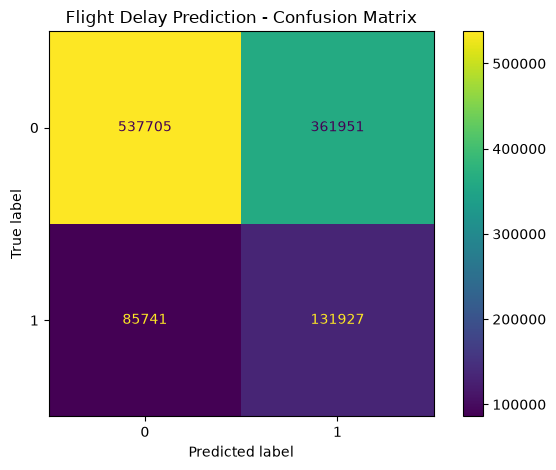

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    values_format="d"
)

plt.title("Flight Delay Prediction - Confusion Matrix")
plt.tight_layout()
plt.show()

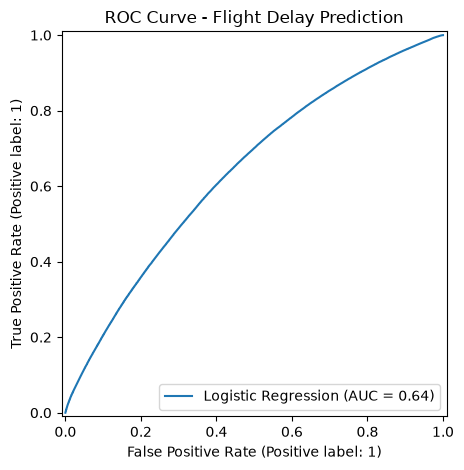

In [24]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

plt.title("ROC Curve - Flight Delay Prediction")
plt.tight_layout()
plt.show()

## 11. Interactive Application Data

The Streamlit app uses lightweight summary files rather than loading the full raw dataset on every page refresh. This keeps the user-facing application responsive while preserving the full analysis in the notebook.

In [25]:
import joblib
from pathlib import Path

# Create model folder
Path("../app").mkdir(exist_ok=True)

# Save trained model
joblib.dump(model, "../app/flight_delay_model.joblib")

print("Model saved successfully.")

Model saved successfully.


In [26]:
# Save dropdown options for the prediction app

app_options = {
    "airlines": sorted(flights["Airline"].dropna().unique().tolist()),
    "origins": sorted(flights["Origin"].dropna().unique().tolist()),
    "destinations": sorted(flights["Dest"].dropna().unique().tolist())
}

joblib.dump(app_options, "../app/app_options.joblib")

print("App options saved successfully.")

App options saved successfully.


In [27]:
# Create lightweight summary files for the Streamlit dashboard

from pathlib import Path

app_dir = Path("../app")
app_dir.mkdir(exist_ok=True)

# Overall metrics
overview = pd.DataFrame({
    "Metric": [
        "Total Flights",
        "Delayed Flights",
        "Delay Rate",
        "Average Arrival Delay",
        "Average Departure Delay"
    ],
    "Value": [
        len(flights),
        int(flights["Delayed"].sum()),
        flights["Delayed"].mean() * 100,
        flights["ArrDelay"].mean(),
        flights["DepDelay"].mean()
    ]
})

overview.to_csv(app_dir / "overview.csv", index=False)

# Airline summary
airline_summary = (
    flights.groupby("Airline")
    .agg(
        Flights=("Delayed", "size"),
        Delayed=("Delayed", "sum"),
        Average_Arrival_Delay=("ArrDelay", "mean")
    )
)

airline_summary["Delay_Rate"] = (
    airline_summary["Delayed"] /
    airline_summary["Flights"] * 100
)

airline_summary.reset_index().to_csv(
    app_dir / "airline_summary.csv",
    index=False
)

# Monthly summary
monthly_summary = (
    flights.groupby("Month")
    .agg(
        Flights=("Delayed", "size"),
        Delayed=("Delayed", "sum")
    )
)

monthly_summary["Delay_Rate"] = (
    monthly_summary["Delayed"] /
    monthly_summary["Flights"] * 100
)

monthly_summary.reset_index().to_csv(
    app_dir / "monthly_summary.csv",
    index=False
)

print("Dashboard summary files created successfully.")

Dashboard summary files created successfully.


## 12. Key Findings

The analysis found an overall flight delay rate of **19.48%**.

- The highest airline delay rate observed was **32.07%** for Commutair Aka Champlain Enterprises, Inc.
- The lowest airline delay rate observed was **8.94%** for Cape Air.
- **August (Month 8)** had the highest monthly delay rate at **24.35%**.
- **September (Month 9)** had the lowest monthly delay rate at **16.65%**.
- The Logistic Regression model achieved **0.599 accuracy**, **0.267 precision**, **0.605 recall**, **0.370 F1 score**, and **0.638 ROC-AUC** on the test set.

These findings show that delay risk varies across airlines and time periods and that the predictive model can provide a useful screening signal, although its false-positive rate means predictions should be interpreted with caution.

## 13. Business Recommendations

Airlines could use historical delay patterns to identify periods with higher operational risk and plan staffing and scheduling support accordingly.

The variation between airline delay rates suggests that airline-level operational performance should be monitored rather than treating all flights as having the same delay risk.

The higher observed delay rate in August indicates that this period may deserve additional operational planning compared with lower-delay periods.

The predictive model can support proactive passenger communication and operational prioritisation, but it should be treated as a decision-support tool rather than a replacement for operational judgement.

## 14. Methodology Justification

The project follows a structured workflow of data preparation, exploratory analysis, statistical testing, feature engineering, predictive modelling and interactive visualisation.

Logistic Regression was selected because the target is binary and the model provides a practical classification baseline with probability estimates.

A stratified train/test split was used to evaluate the model on unseen data. Categorical features were encoded and numerical features were prepared through a preprocessing pipeline.

Streamlit was selected to present the analysis and prediction model through an interactive interface that can be used without running the notebook manually.

## 15. Analytical Approach

1. Load and inspect the historical flight dataset.
2. Remove cancelled and diverted flights from the delay analysis.
3. Remove rows with a missing target.
4. Create time-based scheduling features.
5. Explore overall, airline-level and monthly delay patterns.
6. Examine numerical relationships with correlation analysis.
7. Test the relationship between departure and arrival delays.
8. Train and evaluate a supervised Logistic Regression classifier.
9. Export lightweight summary data and the trained model for the Streamlit application.
10. Communicate findings, limitations and recommendations.

## 16. Project Reflection

This project involved working through the complete data analysis process, from loading and cleaning a large real-world dataset to exploratory analysis, statistical testing, machine learning and interactive visualisation.

A key technical challenge was working efficiently with a large dataset. The final application addresses this by using lightweight summary files instead of repeatedly loading the full raw data.

The project developed practical experience with feature engineering, classification modelling, model evaluation and Streamlit application development.

The final solution demonstrates how data analytics and predictive modelling can be combined to investigate a real-world operational problem and communicate useful findings to users.